In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import json
import statistics
import numpy as np


def std_bar(mean, std):
    tmp_mean = np.array(mean)
    tmp_std = np.array(std)
    
    return tmp_mean - tmp_std, tmp_mean + tmp_std


def plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach):


    f_name = "Lime"
    if "lime" not in fa_approach:
        f_name = "Kernel SHAP"
        
    num = 16
    
    
    d_names = {
        "rte":"RTE",
        "arc_challenge":"ARC Challenge",
        "openbookqa":"OpenBookQA",
        "boolq":"BoolQ",
        "arc_easy":"ARC Easy"
    }


    colors = {"s":"#fc5e03",
              "s0.1":"#fc7703",
              "s0.2":"#fc9003",
              "s0.3":"#fca903",
              "s0.4":"#fcc203",
              "s0.5":"#fcdb03",
              
              "c":"#030ffc",
              "c0.1":"#033dfc",
              "c0.2":"#035efc",
              "c0.3":"#0394fc",
              "c0.4":"#03bafc",
              "c0.5":"#03cafc",
              }
    for dataset in datasets:
        
        res_to_plot = {}
        
        for partial_comp in ["0.1","0.2","0.3","0.4","0.5"]:
            res_to_plot[partial_comp] = {}
            
            if tmp_path_unpruned is not None:
                acc = 0
                s_unpruned = 0
                c_unpruned = 0
                
                for i in range(3):
                    
                    out_file = open(tmp_path_unpruned+model_name+"_"+fa_approach+"_res_3d_"+str(i)+".json", "r")
                    out = json.load(out_file)
                    out_file.close()
                    
                    s_unpruned += np.mean([out[dataset]["partial_suff"][it][partial_comp] for it in range(len(out[dataset]["partial_suff"])) if out[dataset]["partial_suff"][it] is not None])
                    c_unpruned += np.mean([out[dataset]["partial_comp"][it][partial_comp] for it in range(len(out[dataset]["partial_comp"])) if out[dataset]["partial_comp"][it] is not None])
                s_unpruned/=3
                c_unpruned/=3
                
                res_to_plot[partial_comp]["s_unpruned"] = s_unpruned
                res_to_plot[partial_comp]["c_unpruned"] = c_unpruned
            
                
            suff = []
            comp = []
            
            std_suff = []
            std_comp = []
            

            for i in range(num):
                
                tmp_suff =[]
                tmp_comp = []
                tmp_accs = []

                out_file = open(tmp_path+model_name+"_"+str(i)+"_"+fa_approach+"_res_3d_0.json", "r")
                out1 = json.load(out_file)
                out_file.close()
            
                out_file = open(tmp_path+model_name+"_"+str(i)+"_"+fa_approach+"_res_3d_1.json", "r")
                out2 = json.load(out_file)
                out_file.close()
                
                out_file = open(tmp_path+model_name+"_"+str(i)+"_"+fa_approach+"_res_3d_2.json", "r")
                out3 = json.load(out_file)
                out_file.close()
                
                    
                
                
                for out in [out1, out2, out3]:
                    
                    tmp_suff.append(np.mean([out[dataset]["partial_suff"][it][partial_comp] for it in range(len(out[dataset]["partial_suff"])) if out[dataset]["partial_suff"][it] is not None]))
                    tmp_comp.append(np.mean([out[dataset]["partial_comp"][it][partial_comp] for it in range(len(out[dataset]["partial_comp"])) if out[dataset]["partial_comp"][it] is not None]))           

                
                suff.append(statistics.mean(tmp_suff))
                comp.append(statistics.mean(tmp_comp))

                std_suff.append(statistics.stdev(tmp_suff))
                std_comp.append(statistics.stdev(tmp_comp))
            
            res_to_plot[partial_comp]["suff"] = suff
            res_to_plot[partial_comp]["comp"] = comp
            res_to_plot[partial_comp]["std_suff"] = std_suff
            res_to_plot[partial_comp]["std_comp"] = std_comp
        
        # Comprehensiveness
        
        print(res_to_plot)

        fig, ax1 = plt.subplots()
        x_values = list(range(1, len(suff) + 1))
        l = len(x_values)
        
        
        for partial_comp in ["0.1","0.2","0.3","0.4","0.5"]:
            
            if tmp_path_unpruned is not None:
                ax1.plot(x_values, [res_to_plot[partial_comp]["c_unpruned"]]*l, label='unpruned '+partial_comp, color=colors["c"+partial_comp], linestyle='--')
            ax1.plot(x_values, res_to_plot[partial_comp]["comp"], label='pruned '+partial_comp, color=colors["c"+partial_comp])
        
        ax1.set_ylabel('Comprehensiveness', fontsize=18)
        plt.title(d_names[dataset], fontsize=20)
        plt.xlabel("# removed attention layers", fontsize=18)
        

        plt.xticks(np.arange(2, 17, 2))
        plt.tick_params(axis='both', which='major', labelsize=14)
        plt.xlim(1,16)
    
        fig.tight_layout()
        plt.savefig("results/plots/partial_comp/suff_comp_"+dataset+"_"+model_name+"_"+fa_approach+"_comprehensiveness.pdf", dpi=600)
        plt.show()
        
        # SUFFICIENCY
        
        fig, ax1 = plt.subplots()
        x_values = list(range(1, len(suff) + 1))
        l = len(x_values)
        
        
        
        for partial_comp in ["0.1","0.2","0.3","0.4","0.5"]:
            if tmp_path_unpruned is not None:
                ax1.plot(x_values, [res_to_plot[partial_comp]["s_unpruned"]]*l, label='unpruned '+partial_comp, color=colors["s"+partial_comp], linestyle='--')
            ax1.plot(x_values, res_to_plot[partial_comp]["suff"], label='pruned '+partial_comp, color=colors["s"+partial_comp])
        
        ax1.set_ylabel('Sufficiency', fontsize=18)
        plt.title(d_names[dataset], fontsize=20)
        plt.xlabel("# removed attention layers", fontsize=18)
        

        plt.xticks(np.arange(2, 17, 2))
        plt.tick_params(axis='both', which='major', labelsize=14)
        plt.xlim(1,16)
        
        fig.tight_layout()
        plt.savefig("results/plots/partial_suff/suff_comp_"+dataset+"_"+model_name+"_"+fa_approach+"_sufficiency.pdf", dpi=600)
        plt.show()


{'0.1': {'s_unpruned': 0.33785071191522836, 'c_unpruned': 0.2166911615375142, 'suff': [0.34089318143160047, 0.33728407872175353, 0.34122858556139, 0.34083500973773195, 0.33758745928271156, 0.34839003232422405, 0.3442842903564125, 0.3320253818701016, 0.3587791397073465, 0.3410745359929462, 0.3484533836365207, 0.32443483096330733, 0.3201424273786749, 0.31669749694943145, 0.2901944643755511, 0.25816988338200436], 'comp': [0.23377878588281242, 0.22630286763781848, 0.23017197494305627, 0.23250880320116676, 0.22853918303561133, 0.23231597771154242, 0.23134114130039055, 0.23111569565008983, 0.24524734429711836, 0.23055184798287692, 0.22779448287744997, 0.19843951917827585, 0.21338199602504831, 0.20821399958701417, 0.1839030103782617, 0.15636280946897282], 'std_suff': [0.010055286499246616, 0.006464440572661388, 0.0069378385405114195, 0.013267373853284142, 0.011610782410125288, 0.016991750220257926, 0.013511758415055735, 0.009718762651990306, 0.0008123651691325245, 0.0061218265818430515, 0.007

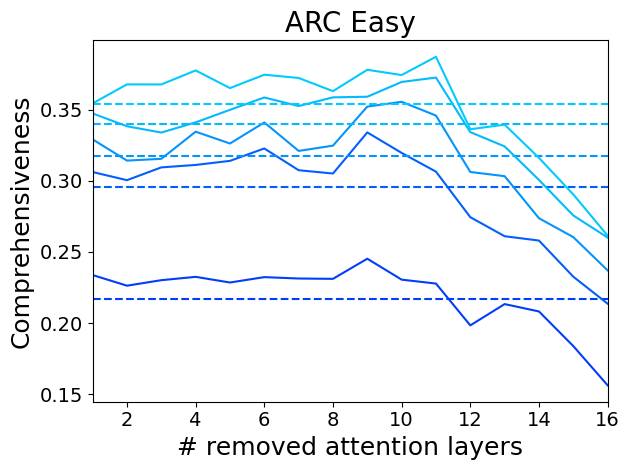

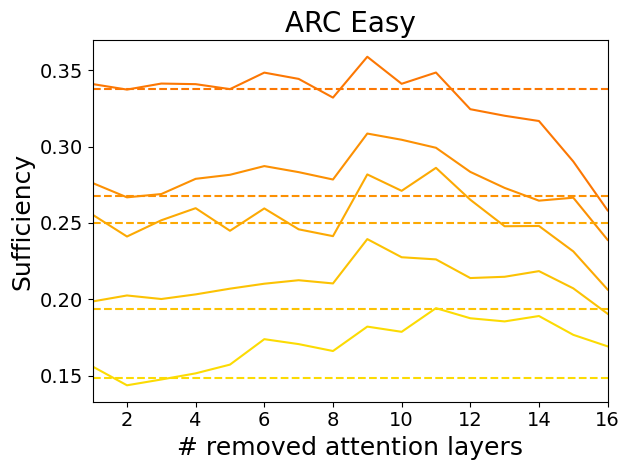

{'0.1': {'s_unpruned': 0.26812364875419, 'c_unpruned': 0.3038842623788169, 'suff': [0.2696597079344287, 0.2662917402955927, 0.28102985105879197, 0.27018905497301493, 0.25706850394564434, 0.2517372975020463, 0.2474617450395275, 0.24648283326159828, 0.26721859806665693, 0.25368075163430437, 0.21789331832037795, 0.21335438491795292, 0.1455828498002973, 0.12423932951144376, 0.10320342693072468, -0.004821667857424725], 'comp': [0.31725500247092153, 0.3208945409787097, 0.3070583788657149, 0.3041945493761159, 0.3182400535908885, 0.30719565372707425, 0.2748782993148664, 0.2817222694556466, 0.25926032546487093, 0.2535450299579408, 0.23840324248403486, 0.27619594082334176, 0.21012411387855018, 0.23419155835481945, 0.23881148851444445, 0.25312654233220067], 'std_suff': [0.014544223263288473, 0.020108950129810444, 0.007806094441456805, 0.008532087796620322, 0.01550921406461866, 0.01812503463686595, 0.012806361466371053, 0.02024978879588976, 0.014243430007085504, 0.0030553075489169056, 0.0234939307

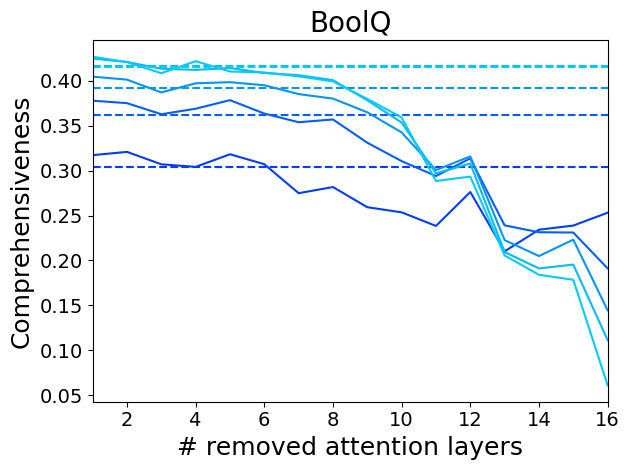

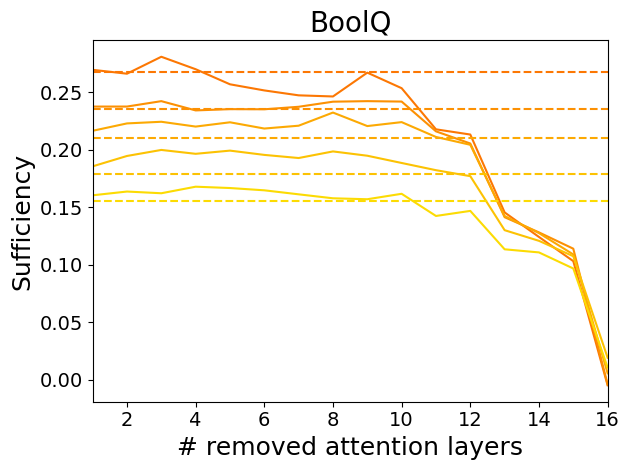

{'0.1': {'s_unpruned': 0.13026973442082893, 'c_unpruned': 0.07805070484023025, 'suff': [0.12083105947698766, 0.13273896534835256, 0.11827838237107342, 0.10805671312481308, 0.0856364382410723, 0.07866721955472333, 0.084649783304544, 0.08265950170743405, 0.08144906490915689, 0.13806194640781358, 0.08061742782234269, 0.07443509949565588, 0.06076535853582768, 0.09060163373901553, 0.11281686251986459, 0.028989054926067043], 'comp': [0.08553446568573501, 0.08729367653890771, 0.08658855617954993, 0.08830879649465738, 0.08592319797975904, 0.0892225991440547, 0.07967834651174424, 0.06763374650346476, 0.09875586527136904, 0.16797546493404242, 0.07187802195601004, 0.05860979053146018, 0.010632558837641231, 0.07647393259959649, 0.09265607740960967, 0.03274950775897823], 'std_suff': [0.005702587853435191, 0.0022044688496452324, 0.008070469581272522, 0.005616514417740636, 0.003533317506138336, 0.00170530120746397, 0.009593979206515458, 0.015243123307077751, 0.009516691784776689, 0.006741760696940843

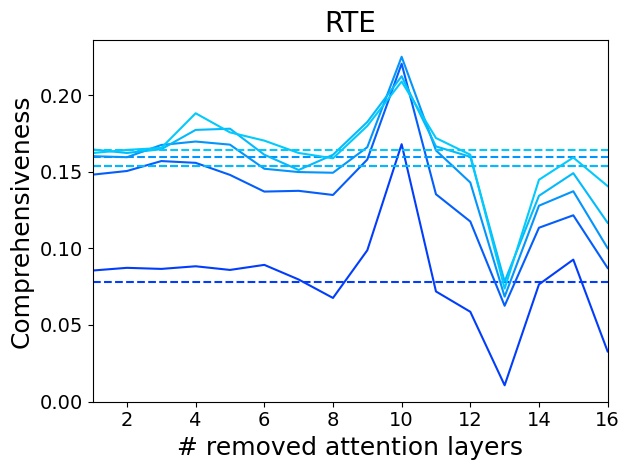

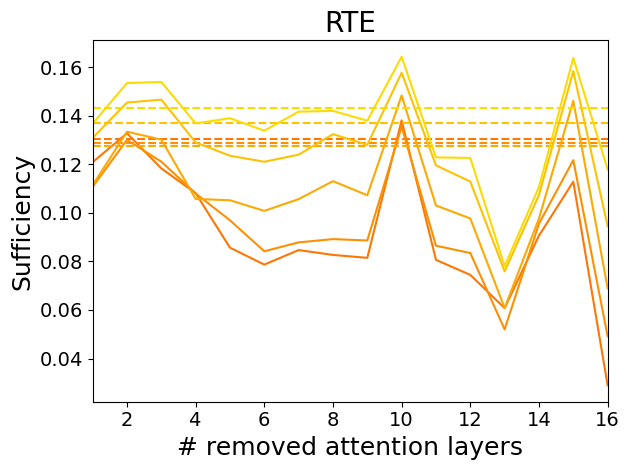

{'0.1': {'s_unpruned': 0.2946657174121401, 'c_unpruned': 0.20967749585185055, 'suff': [0.29749701986884336, 0.28290301766001846, 0.28332643438065513, 0.2910407582549124, 0.28044444844112687, 0.28711705397569215, 0.28539802963892674, 0.29777256897097626, 0.3010642925934446, 0.2895115151916745, 0.2900052389891474, 0.2583509956391662, 0.24192054347850045, 0.2155632180278589, 0.22951211780335815, 0.17332037352677382], 'comp': [0.21051160986107556, 0.22501396539156265, 0.21788041596625693, 0.2261859371759905, 0.22021939276404467, 0.21458607027644008, 0.2069537965502343, 0.21652116986096262, 0.2146551182340862, 0.1977299854694025, 0.20064206074592308, 0.18606216353948113, 0.15836598013829256, 0.15286379882832868, 0.14366434772003422, 0.10329983865930366], 'std_suff': [0.01410976384029799, 0.013128278381092569, 0.026769690119618182, 0.026240191606836463, 0.014393470415314965, 0.021679812504443407, 0.030464588377801017, 0.02722105108725533, 0.04325772684272505, 0.031227314807997175, 0.02473206

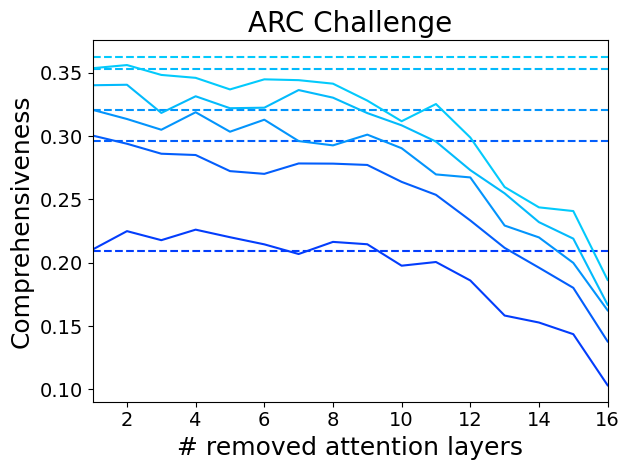

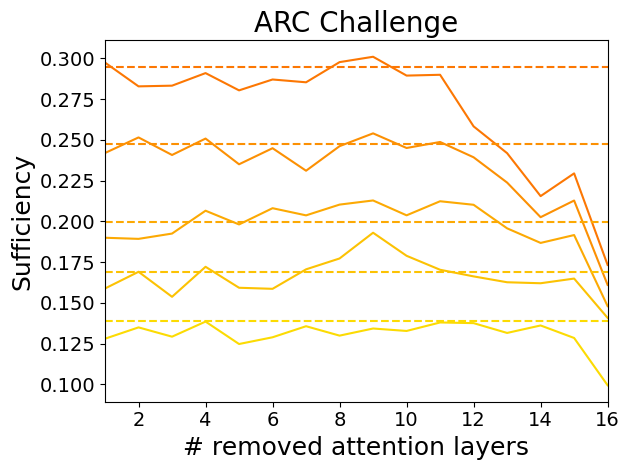

{'0.1': {'s_unpruned': 0.30219187589000546, 'c_unpruned': 0.15803942822877212, 'suff': [0.3020074779966338, 0.30040563263224385, 0.302539555164616, 0.31907911635638864, 0.3231358673576099, 0.32415508164951895, 0.3055979845614884, 0.321524820058467, 0.3196810303212901, 0.3079908585389934, 0.28664557724004225, 0.2594854311273475, 0.25308206016181173, 0.23310265176524375, 0.21636052251387328, 0.19039276329115754], 'comp': [0.1614954395112113, 0.16527378795865838, 0.16096193476109755, 0.16721285593528123, 0.18074653463092502, 0.17966897331378864, 0.1647807623284705, 0.16192104687286446, 0.15341093948348505, 0.1495502979604091, 0.1454170882430113, 0.14239886553946643, 0.12638983084917976, 0.12931209206314656, 0.11930455335059427, 0.08835704862566392], 'std_suff': [0.009067192531180794, 0.01454674816449288, 0.015456796525526216, 0.011543111927210966, 0.013936814765593835, 0.01685435544999605, 0.01933101863315556, 0.014574123768648015, 0.010338169369882794, 0.009302021183583309, 0.00845069379

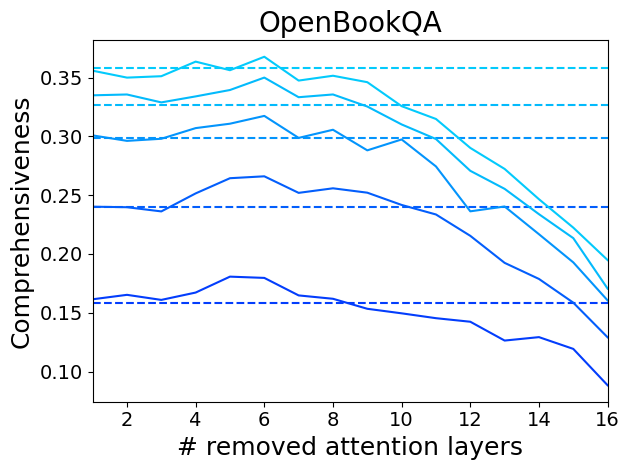

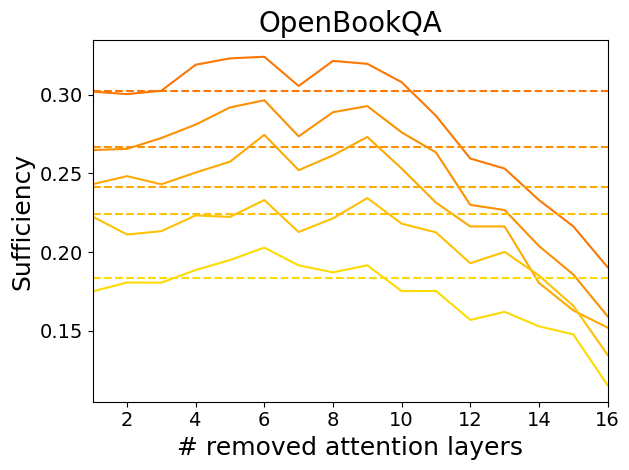

In [14]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Mistral-7B-v0.1"
tmp_path = "./results/pruned/intermediate/seeds/mistralai/"
tmp_path2 = "./results/pruned/intermediate/mistralai/"
tmp_path_unpruned = "./results/unpruned/intermediate/seeds/mistralai/"
fa_approach = "ks"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Mistral-7B-v0.1"
tmp_path = "./results/pruned/intermediate/seeds/mistralai/"
tmp_path2 = "./results/pruned/intermediate/mistralai/"
tmp_path_unpruned = "./results/unpruned/intermediate/seeds/mistralai/"
fa_approach = "lime"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Llama-2-7b-hf"
tmp_path = "./results/pruned/intermediate/seeds/meta-llama/"
tmp_path2 = "./results/pruned/intermediate/meta-llama/"
tmp_path_unpruned = "./results/unpruned/intermediate/seeds/meta-llama/"
fa_approach = "lime"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)

In [ ]:
datasets = ["arc_easy","boolq","rte","arc_challenge","openbookqa"]
model_name = "Llama-2-7b-hf"
tmp_path = "./results/pruned/intermediate/seeds/meta-llama/"
tmp_path2 = "./results/pruned/intermediate/meta-llama/"
tmp_path_unpruned = "./results/unpruned/intermediate/seeds/meta-llama/"
fa_approach = "ks"

plot_res(tmp_path, tmp_path2, tmp_path_unpruned, model_name, datasets, fa_approach)